# Quickstart

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/get_started/quickstart.ipynb)

In January 1986, the Space Shuttle Challenger broke apart shortly after launch because an O-ring seal in one of its rocket boosters failed during unusually cold weather.
This notebook fits a Bayesian logistic regression of O-ring damage given the temperature at launch based on data from 23 earlier shuttle launches.
It then forecasts the probability of damage at the estimated temperature of 31°F near the rocket booster at the time of launch. 
The notebook extends the quick example of the [home page](../index.md) into a short workflow:

1. **Specify** a model in terms of its prior and likelihood.
2. **Fit** the model with `condition_on`.
3. **Check** the fit with MCMC diagnostics and a posterior predictive check.
4. **Forecast** using the posterior.


## Setup

On Google Colab, the next cell installs ProbPipe and reads in the data from GitHub.
Otherwise, the notebook reads the copy of the data in the repository, and ProbPipe must already be installed, as [Installation](installation.md) describes.
The plots require matplotlib, which Colab includes. 

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    data_path = "../tutorials/data/challenger.csv"
else:
    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    data_path = "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/docs/tutorials/data/challenger.csv"

## The data

We first read in the data using pandas. 
Each row of the data is a launch, with its flight number, the temperature at launch in °F, and a damage indicator that is 1 if an O-ring was damaged and 0 otherwise.

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Bernoulli,
    Normal,
    NumericArraySpec,
    condition_on,
    conditional_distribution,
    function,
    mean,
    predictive_check,
    quantile,
    workflow_run,
)
from probpipe.diagnostics import add_mcmc_diagnostics

data = pd.read_csv(data_path)
temperature = jnp.asarray(data["temperature"], dtype=jnp.float32)
damage = jnp.asarray(data["damage"], dtype=jnp.int32)

print("number of launches:", len(data))
print("launches with O-ring damage:", int(damage.sum()))
print("temperature of the coldest launch (°F):", int(data["temperature"].min()))

number of launches: 23
launches with O-ring damage: 7
temperature of the coldest launch (°F): 53


Here we plot the data. Notice the forecast temperature is far outside the range of the data, so predicting O-ring failure for the Challenger requires extrapolation. But, notably, all four launches below 65°F had damage. 

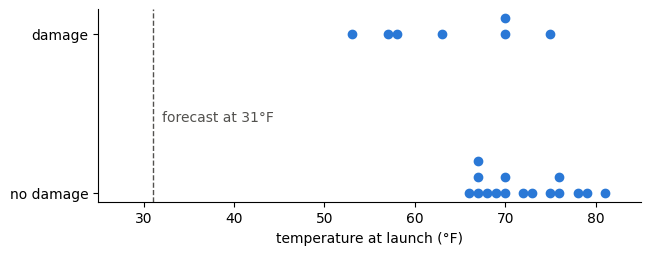

In [3]:
# Launches with the same temperature and outcome are stacked, so that each one shows.
stack = data.groupby(["temperature", "damage"]).cumcount()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.scatter(data["temperature"], data["damage"] + 0.1 * stack, color="#2a78d6", zorder=2)
ax.axvline(31, color="#52514e", linestyle="--", linewidth=1)
ax.text(32, 0.45, "forecast at 31°F", color="#52514e")
ax.set_xlim(25, 85)
ax.set_yticks([0, 1], ["no damage", "damage"])
ax.set_xlabel("temperature at launch (°F)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 1. Specify the model

We will use a logistic regression model, which relates the log-odds of damage at launch $i$ to the temperature through an intercept and a slope:

$$\operatorname{logit} P(\text{damage}_i = 1) = \text{intercept} + \text{slope} \times \text{temperature}_i.$$

The model has three parts:

- **The prior** is the product of two normal distributions, and `*` composes them into one joint distribution of the intercept and the slope.
- **The likelihood** is a conditional distribution: given an intercept and a slope, it is the distribution of the 23 damage indicators. `conditional_distribution` builds it from a function that returns that distribution, and `given_spec` declares each given value a scalar.
- **The model** composes the likelihood with the prior into the joint distribution of the parameters and the data.

In [4]:
prior = (Normal("intercept", 0.0, 10.0) * Normal("slope", 0.0, 1.0)).with_label("prior")

likelihood = conditional_distribution(
    "likelihood",
    lambda intercept, slope: Bernoulli("damage", logits=intercept + slope * temperature),
    given_spec={"intercept": NumericArraySpec(()), "slope": NumericArraySpec(())},
)

model = (likelihood * prior).with_label('oring_model')
print("model:", model)

model: FactoredDistribution(
    'oring_model',
    factors=(
        ConditionalDistribution(
            'likelihood',
            given=('intercept', 'slope'),
            event_spec=OutputSpec(
                damage=NumericArraySpec(shape=(23,), dtype=int32, support=boolean),
            ),
        ),
        Normal('intercept', loc=0.0, scale=10.0),
        Normal('slope', loc=0.0, scale=1.0),
    ),
)


## 2. Fit the model

`condition_on(model, observed)` fixes the damage indicators at their observed values and returns the posterior distribution of the intercept and the slope.
ProbPipe selects how to compute it, and `condition_on.check` reports the selection without running it:

In [5]:
observed = {"damage": damage}
report = condition_on.check(model, observed)
print("selected route and method:", report.selected.method_name)

selected route and method: bayes/blackjax_nuts


No exact method applies to this model, since the posterior of a logistic regression has no closed form.
`condition_on` therefore takes the route `bayes`, which forms the unnormalized posterior and passes it to an inference method.
The inference method `blackjax_nuts` then draws from the posterior with BlackJAX's No-U-Turn Sampler (NUTS).
In a notebook, displaying `report` shows a table of every route that `condition_on` evaluated, with the reason each other route declined.

The fit runs inside `workflow_run(seed=0)`, which seeds the random draws of the block, so rerunning the cell reproduces the posterior.

In [6]:
with workflow_run(seed=0):
    posterior = condition_on(model, observed)

print("posterior:", posterior)
print("method that produced the posterior:", posterior.provenance.metadata["method"])
print("posterior mean of the intercept:", round(float(mean(posterior["intercept"])), 2))
print("posterior mean of the slope:", round(float(mean(posterior["slope"])), 3))

posterior: EmpiricalDistribution(
    'oring_model | damage',
    atoms=NumericRecordBatch(
        'posterior',
        levels={'chain': 4, 'draw': 1000},
        fields=('intercept', 'slope'),
    ),
)
method that produced the posterior: blackjax_nuts
posterior mean of the intercept: 11.56
posterior mean of the slope: -0.182


The posterior is an `EmpiricalDistribution` of 4 chains of 1,000 draws each.
Its provenance records the operation that produced it, and the provenance's `metadata` provides the route and the method.
The slope's posterior mean of −0.18 indicates that each degree colder raises the log-odds of damage by about 0.18.

## 3. Check the fit

### MCMC diagnostics

NUTS returns correlated draws from four chains, so we use two diagnostics to evaluate accuracy: 

- **R-hat** compares the variability within each chain with the variability between the chains. Values below 1.01 indicate that the chains agree.
- **Effective sample size (ESS)** is the number of independent draws that the correlated draws are equivalent to when used to estimate the mean of the distribution (bulk) and its tails (tail).

`add_mcmc_diagnostics` computes both and records them on the posterior, and `posterior.diagnostics` reads them:

In [7]:
add_mcmc_diagnostics(posterior)
print(posterior.diagnostics.summary_table())

Parameter     R-hat     ESS bulk    ESS tail    MCSE mean   
------------------------------------------------------------
intercept     1.0053    480.5920    525.0845    0.2444      
slope         1.0053    479.2695    529.6914    0.0036      

✓  All available diagnostics passed.


R-hat is below 1.01 for both parameters, and each effective sample size exceeds the threshold of 400 below which `add_mcmc_diagnostics` provides a warning.
`posterior.annotations["arviz"]` holds the draws as ArviZ data, with one variable for each parameter, so ArviZ's summaries and plots, such as `arviz.summary`, also apply to them.

### The posterior draws

> **AI-generated section.** An AI assistant changed this section after the page was reviewed, and no maintainer has reviewed the change yet.

ArviZ's plots apply to the posterior's ArviZ data.
A pair plot shows the joint posterior of the intercept and the slope, and an autocorrelation plot shows how strongly each chain's successive draws depend on one another.

posterior correlation of the intercept and the slope: -0.99


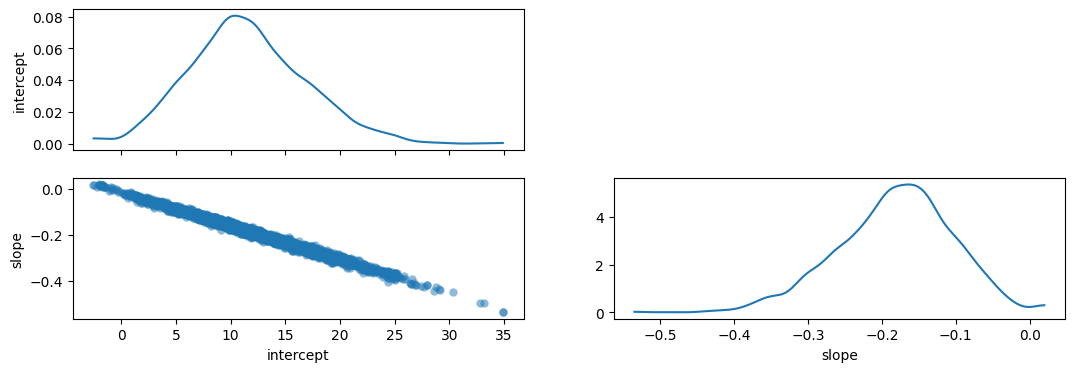

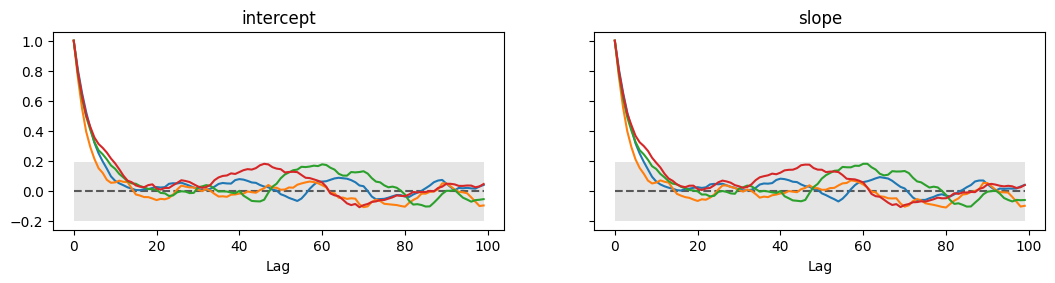

In [8]:
import arviz as az

intercept = np.ravel(posterior.atoms["intercept"].values)
slope = np.ravel(posterior.atoms["slope"].values)
print("posterior correlation of the intercept and the slope:", round(float(np.corrcoef(intercept, slope)[0, 1]), 2))

arviz_data = posterior.annotations["arviz"]
az.plot_pair(arviz_data)
plt.show()
az.plot_autocorr(arviz_data)
plt.show()

The draws lie along a narrow ridge, with a posterior correlation near −1.
Every launch was at 53°F or warmer, far from 0°F, so a larger intercept fits the data as well as a smaller one does when the slope falls to offset it.
The sampler moves along the ridge in short steps, so each chain's successive draws are correlated, and the autocorrelation falls near zero only after about 20 draws.
For that reason the 4,000 draws are worth only about 480 independent ones, the effective sample sizes above.
Centering the temperature at its mean makes the intercept the log-odds of damage at the average launch temperature, which removes most of the correlation and raises the effective sample sizes to about 2,000.

### Posterior predictive check

A posterior predictive check simulates replicated data from the fitted model and compares them with the observed data through test statistics.
Each replication draws an intercept and a slope from the posterior, and then 23 damage indicators from the likelihood at those values.
`predictive_check` takes the likelihood, the posterior over the likelihood's given values, the statistics, and the observed data.
Two statistics suit binary data like these:

- `damaged_launches`: the number of launches with damage;
- `damaged_cold_launches`: the number of damaged launches among the four below 65°F, which tests the model at the cold end of the data, where it is nearest the forecast temperature.

In [9]:
cold = temperature < 65


def damaged_launches(damage):
    return jnp.sum(damage)


def damaged_cold_launches(damage):
    return jnp.sum(jnp.where(cold, damage, 0))


with workflow_run(seed=1):
    check = predictive_check(
        likelihood, posterior, [damaged_launches, damaged_cold_launches], observed
    )

statistics = ["damaged_launches", "damaged_cold_launches"]
pd.DataFrame(
    {
        name: {
            "observed": float(check[f"{name}/observed_statistic"]),
            "mean of the replications": float(mean(check[f"{name}/replicated_statistics"])),
            "p-value": float(check[f"{name}/p_value"]),
        }
        for name in statistics
    }
).T

,observed,mean of the replications,p-value
damaged_launches,7.0,6.982,0.526
damaged_cold_launches,4.0,2.828,0.290


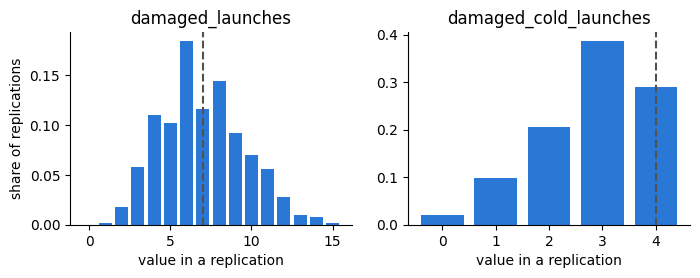

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2.5))
for ax, name in zip(axes, statistics):
    replications = np.asarray(check[f"{name}/replicated_statistics"].atoms).astype(int)
    counts = np.bincount(replications)
    ax.bar(range(len(counts)), counts / len(replications), color="#2a78d6")
    ax.axvline(float(check[f"{name}/observed_statistic"]), color="#52514e", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("value in a replication")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("share of replications")
plt.show()

The bars show the distribution of each statistic over 500 replications, and the dashed line marks its observed value.
A p-value is the share of replications whose statistic is at least the observed one, so a p-value near 0 or 1 signals that the model misses that feature of the data.
The p-values are 0.53 for `damaged_launches` and 0.29 for `damaged_cold_launches`, so neither statistic provides evidence of misfit.

## 4. Forecast

The probability of damage at a temperature $t$ is the logistic function of $\text{intercept} + \text{slope} \times t$.
`damage_probability` computes that value at $t =$ 31°F for one intercept and one slope, and `@function` makes it a ProbPipe function.

In [11]:
@function
def damage_probability(intercept, slope):
    return jax.nn.sigmoid(intercept + slope * 31.0)


with workflow_run(seed=2):
    risk = damage_probability(posterior["intercept"], posterior["slope"])

print("number of draws used to forecast:", risk.num_atoms)
print("P(damage at 31°F), posterior mean:", round(float(mean(risk)), 3))
print("P(damage at 31°F), 90% interval:", quantile(risk, jnp.array([0.05, 0.95])).values)

number of draws used to forecast: 256
P(damage at 31°F), posterior mean: 0.96


P(damage at 31°F), 90% interval: [0.7568541  0.99997556]


`damage_probability` is defined for a single pair of inputs, but here it receives the posterior's fields `intercept` and `slope`, which are distributions.
ProbPipe therefore *lifts* the function: it evaluates the function at 256 joint draws of the intercept and the slope, and it returns the distribution of the results. 
Using 
`damage_probability.with_options(n_broadcast_samples=1000)` would evaluate the function at 1,000 draws instead.

The posterior mean of the probability of damage at 31°F is 0.96, and its 90% interval runs from 0.76 to almost 1.
The forecast extrapolates 22°F below the coldest launch in the data, so it depends on the logistic form of the model as well as on the data.

## Next steps

- [Installation](installation.md) lists the extras, which add inference methods and models written in Stan or PyMC.
- The [first tutorial](../tutorials/01_first_analysis.ipynb) begins a forecasting problem that the tutorials follow from a first posterior to simulation-based inference.
- The [API reference](../api/index.md) documents every public name.

> **Human-validated** by Jonathan Huggins on 2026-10-03.